# Result comparison

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind_from_stats

In [2]:
run_name = "run_baseline_all_most_expressive_v2"

## Get run results

In [3]:
def get_average_raster(all_rasters: np.ndarray, clusters: np.ndarray) -> np.ndarray:
    """
    all_rasters (N, n_units, n_timestamps)
    clusters (N,)

    return (C, n_units, n_timestamps)
    """
    n_clusters = clusters.max()+1
    results = np.empty((n_clusters,all_rasters.shape[1],all_rasters.shape[2]))
    for c in range(n_clusters):
        results[c,:,:] = all_rasters[clusters==c].mean(axis=0)
    return results

In [4]:
i = np.load("./complete_pipeline/out/"+run_name+"/original_i.npy")
i_clust = np.load("./complete_pipeline/out/"+run_name+"/cs_clusters.npy")
df_i = pd.DataFrame(np.column_stack((i,i_clust)),columns=["orientation","spatial_frequency","phase","CS_class"])
num_i_clusters = int(df_i.CS_class.max()+1)
j = np.load("./complete_pipeline/out/"+run_name+"/original_j.npy")
j_clust = np.load("./complete_pipeline/out/"+run_name+"/eft_clusters.npy")
num_j_clusters = j_clust.max()+1
# j_norm = (j-j.mean(axis=2,keepdims=True))/(j.std(axis=2,keepdims=True)+1e-8)
avg_rasters = get_average_raster(j,j_clust)

## Analyze CS classes (I)

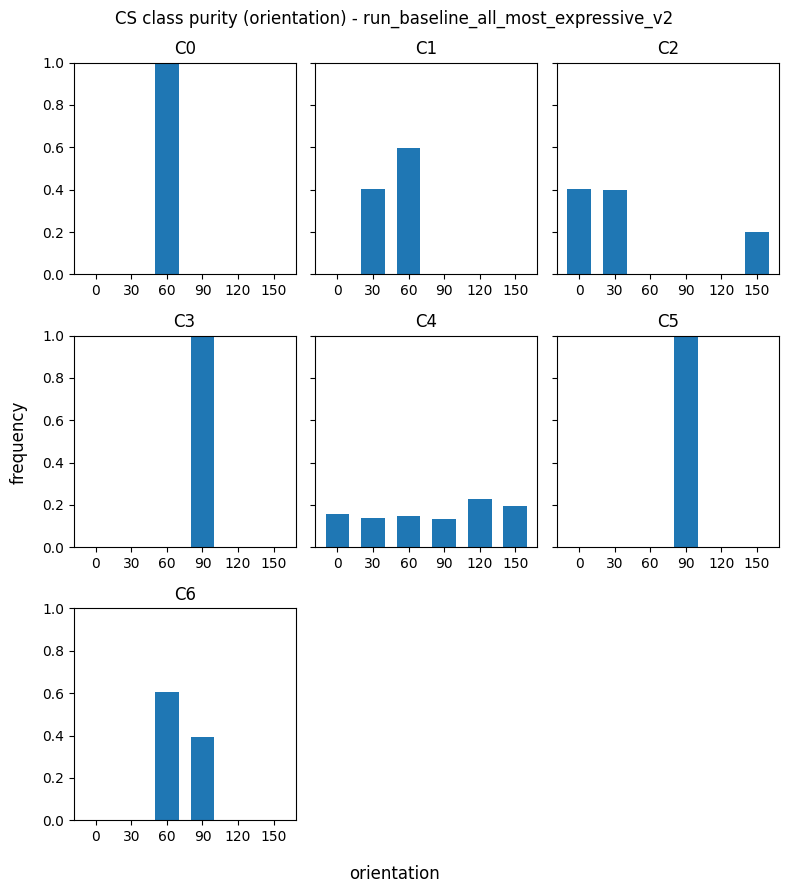

In [5]:
n_cols = 3
n_rows = num_i_clusters//n_cols + 1 if num_i_clusters%n_cols!=0 else num_i_clusters//n_cols
fig, ax = plt.subplots(nrows=n_rows,ncols=n_cols,sharey=True,figsize=(8,9))
for c in range(num_i_clusters):
    clust_data = df_i[df_i.CS_class==c]
    ax[c//n_cols,c%n_cols].hist(clust_data.orientation,weights=[1/clust_data.shape[0]]*clust_data.shape[0],bins=[-10,10,20,40,50,70,80,100,110,130,140,160])
    ax[c//n_cols,c%n_cols].set_title(f"C{c}")
    ax[c//n_cols,c%n_cols].set_xticks([0,30,60,90,120,150])
for c in range(num_i_clusters,n_cols*n_rows):
    ax[c//n_cols,c%n_cols].axis("off")
ax[0,0].set_ylim(0,1)
fig.suptitle(f"CS class purity (orientation) - {run_name}")
fig.supxlabel("orientation")
fig.supylabel("frequency")
plt.tight_layout()
plt.show()

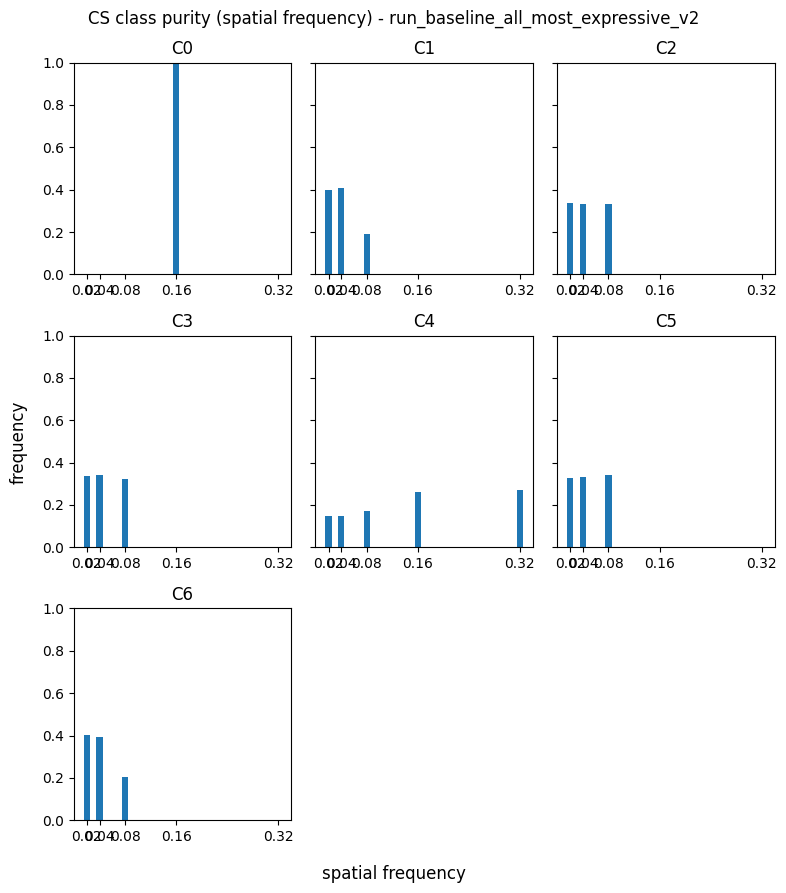

In [6]:
n_cols = 3
n_rows = num_i_clusters//n_cols + 1 if num_i_clusters%n_cols!=0 else num_i_clusters//n_cols
fig, ax = plt.subplots(nrows=n_rows,ncols=n_cols,sharey=True,figsize=(8,9))
for c in range(num_i_clusters):
    clust_data = df_i[df_i.CS_class==c]
    ax[c//n_cols,c%n_cols].hist(clust_data.spatial_frequency,weights=[1/clust_data.shape[0]]*clust_data.shape[0],bins=[0.015,0.025,0.035,0.045,0.075,0.085,0.155,0.165,0.315,0.325])
    ax[c//n_cols,c%n_cols].set_title(f"C{c}")
    ax[c//n_cols,c%n_cols].set_xticks([0.02,0.04,0.08,0.16,0.32])
for c in range(num_i_clusters,n_cols*n_rows):
    ax[c//n_cols,c%n_cols].axis("off")
ax[0,0].set_ylim(0,1)
fig.suptitle(f"CS class purity (spatial frequency) - {run_name}")
fig.supxlabel("spatial frequency")
fig.supylabel("frequency")
plt.tight_layout()
plt.show()

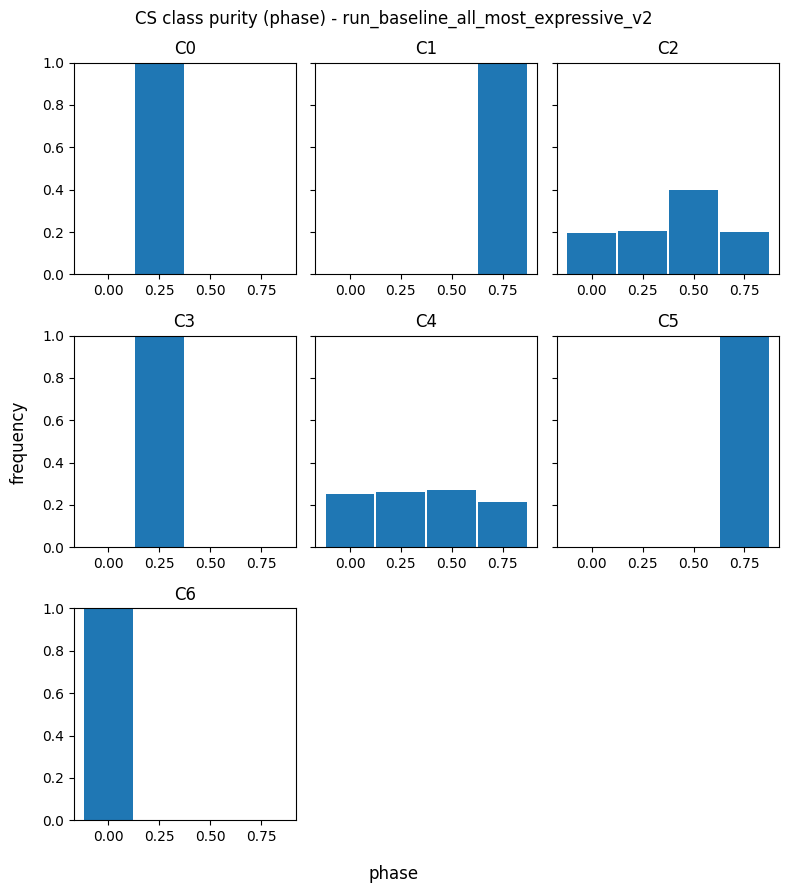

In [7]:
n_cols = 3
n_rows = num_i_clusters//n_cols + 1 if num_i_clusters%n_cols!=0 else num_i_clusters//n_cols
fig, ax = plt.subplots(nrows=n_rows,ncols=n_cols,sharey=True,figsize=(8,9))
for c in range(num_i_clusters):
    clust_data = df_i[df_i.CS_class==c]
    ax[c//n_cols,c%n_cols].hist(clust_data.phase,weights=[1/clust_data.shape[0]]*clust_data.shape[0],bins=[-0.12,0.12,0.13,0.37,0.38,0.62,0.63,0.87])
    ax[c//n_cols,c%n_cols].set_title(f"C{c}")
    ax[c//n_cols,c%n_cols].set_xticks([0,0.25,0.50,0.75])
for c in range(num_i_clusters,n_cols*n_rows):
    ax[c//n_cols,c%n_cols].axis("off")
ax[0,0].set_ylim(0,1)
fig.suptitle(f"CS class purity (phase) - {run_name}")
fig.supxlabel("phase")
fig.supylabel("frequency")
plt.tight_layout()
plt.show()

In [8]:
clust_comp = pd.DataFrame(index=range(num_i_clusters),columns=["orientation","spatial_frequency","phase"])
clust_comp.index.set_names("CS_class",inplace=True)
for c in range(num_i_clusters):
    clust_data = df_i[df_i.CS_class==c]
    clust_comp.loc[c,"orientation"] = clust_data.orientation.sort_values().unique()
    clust_comp.loc[c,"spatial_frequency"] = clust_data.spatial_frequency.sort_values().unique()
    clust_comp.loc[c,"phase"] = clust_data.phase.sort_values().unique()
clust_comp

,orientation,spatial_frequency,phase
CS_class,,,
0,[60.0],[0.16],[0.25]
1,"[30.0, 60.0]","[0.02, 0.04, 0.08]",[0.75]
2,"[0.0, 30.0, 150.0]","[0.02, 0.04, 0.08]","[0.0, 0.25, 0.5, 0.75]"
3,[90.0],"[0.02, 0.04, 0.08]",[0.25]
4,"[0.0, 30.0, 60.0, 90.0, 120.0, 150.0]","[0.02, 0.04, 0.08, 0.16, 0.32]","[0.0, 0.25, 0.5, 0.75]"
5,[90.0],"[0.02, 0.04, 0.08]",[0.75]
6,"[60.0, 90.0]","[0.02, 0.04, 0.08]",[0.0]


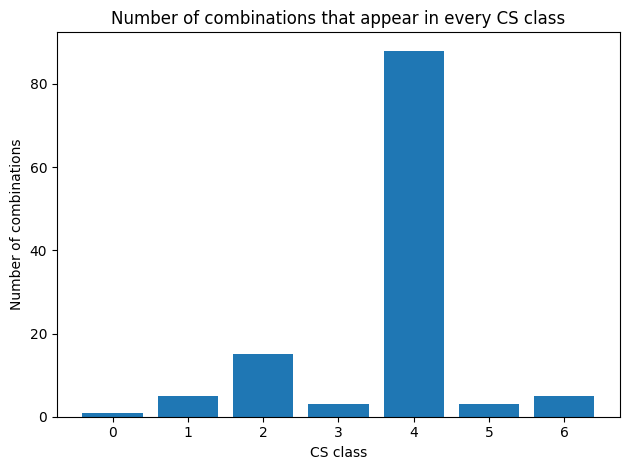

In [9]:
df_i["combination"] = df_i.groupby(["orientation","spatial_frequency","phase"]).ngroup()
clust_comb = pd.DataFrame(index=range(num_i_clusters),columns=["combinations"])
clust_comb.index.set_names("CS_class",inplace=True)
for c in range(num_i_clusters):
    clust_data = df_i[df_i.CS_class==c]
    clust_comb.loc[c,"combinations"] = clust_data.combination.sort_values().unique().size
plt.bar(clust_comb.index,clust_comb.combinations,width=0.8)
plt.title("Number of combinations that appear in every CS class")
plt.xlabel("CS class")
plt.ylabel("Number of combinations")
plt.tight_layout()
plt.show()

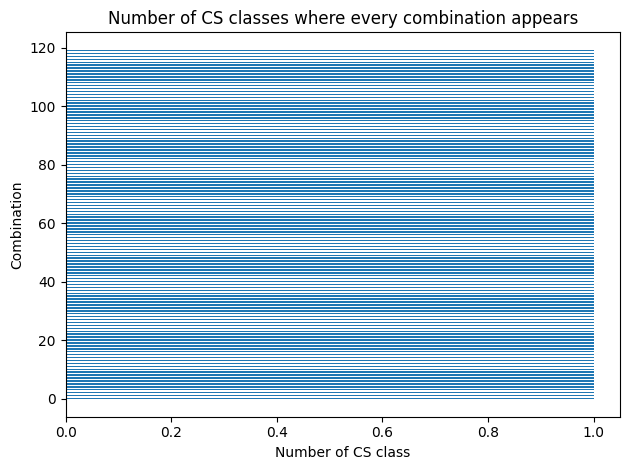

In [10]:
comb_clust = pd.DataFrame(index=range(df_i["combination"].unique().size),columns=["CS_class"])
comb_clust.index.set_names("combination",inplace=True)
for c in range(df_i["combination"].unique().size):
    comb_data = df_i[df_i.combination==c]
    comb_clust.loc[c,"CS_class"] = comb_data.CS_class.sort_values().unique().size
plt.barh(comb_clust.index,comb_clust.CS_class,height=0.5)
plt.title("Number of CS classes where every combination appears")
plt.xlabel("Number of CS class")
plt.ylabel("Combination")
plt.tight_layout()
plt.show()

## Analyze EFT classes (J)

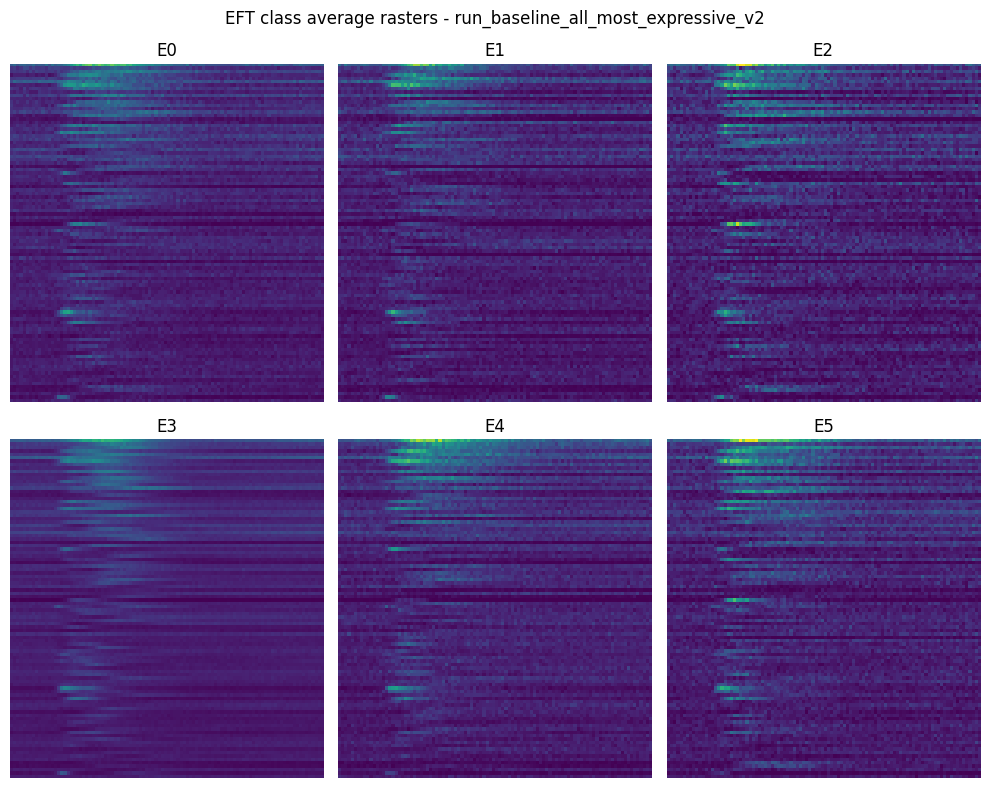

In [11]:
n_cols = 3
n_rows = num_j_clusters//n_cols + 1 if num_j_clusters%n_cols!=0 else num_j_clusters//n_cols
fig, ax = plt.subplots(nrows=n_rows,ncols=n_cols,figsize=(10,8))
v = avg_rasters.max()
for c in range(num_j_clusters):
    ax[c//n_cols,c%n_cols].imshow(avg_rasters[c],aspect="auto",vmin=0,vmax=v)
    ax[c//n_cols,c%n_cols].set_title(f"E{c}")
    ax[c//n_cols,c%n_cols].axis("off")
for c in range(num_j_clusters,n_cols*n_rows):
    ax[c//n_cols,c%n_cols].axis("off")
fig.suptitle(f"EFT class average rasters - {run_name}")
plt.tight_layout()
plt.show()

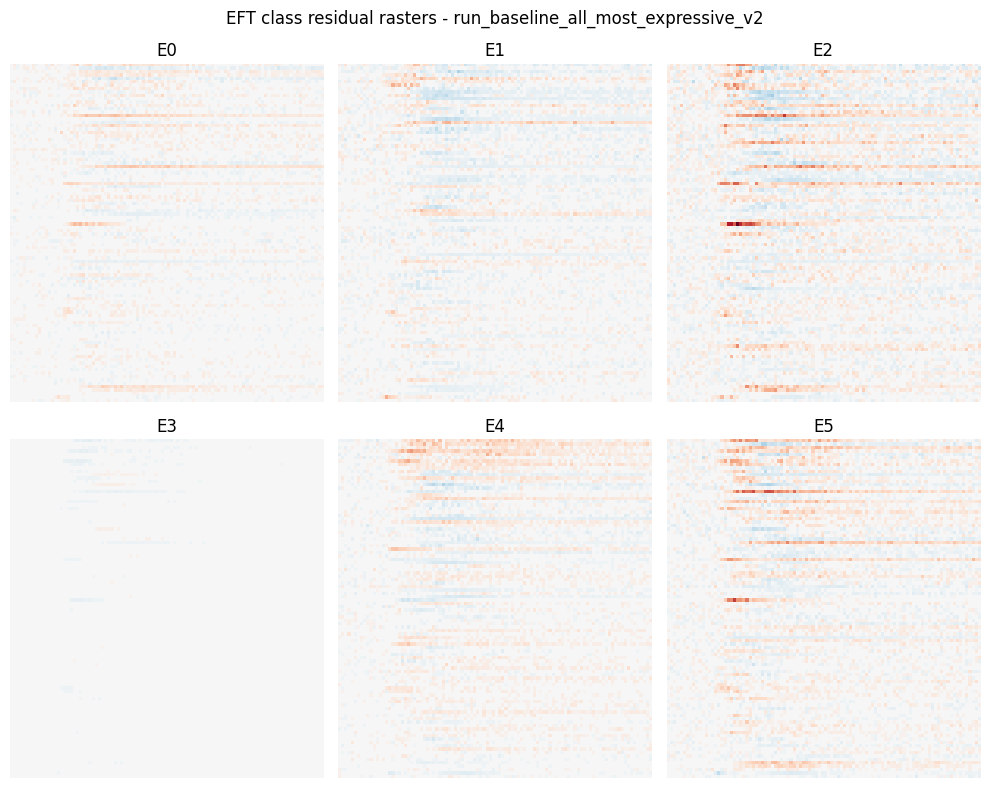

In [12]:
global_avg = j.mean(axis=0)
residuals = avg_rasters-global_avg[None,:,:]
residuals = np.where(np.abs(residuals)<0.01,0,residuals)
n_cols = 3
n_rows = num_j_clusters//n_cols + 1 if num_j_clusters%n_cols!=0 else num_j_clusters//n_cols
v = np.max(np.abs(residuals))
fig, ax = plt.subplots(nrows=n_rows,ncols=n_cols,figsize=(10,8))
for c in range(num_j_clusters):
    im = ax[c//n_cols,c%n_cols].imshow(residuals[c],aspect="auto",vmin=-v,vmax=v,cmap="RdBu_r")
    ax[c//n_cols,c%n_cols].set_title(f"E{c}")
    ax[c//n_cols,c%n_cols].axis("off")
for c in range(num_j_clusters,n_cols*n_rows):
    ax[c//n_cols,c%n_cols].axis("off")
fig.suptitle(f"EFT class residual rasters - {run_name}")
plt.tight_layout()
plt.show()

For each raster : 
* total activations
* total activations by unit (*not informative*)
* total activations by timestamp (*not informative*)
* average activations (*not informative*)
* average activations by unit (*not informative*)
* average activations by timestamp (*not informative*)
* max activations
* max activations by unit (*not informative*)
* max activations by timestamp (*not informative*)
* proportion of active units
* proportion of silence timestamps

For each cluster : 
* portrait of average raster
* average (and std) of all raster metrics

In [13]:
def get_raster_level_metrics(all_rasters: np.ndarray) -> pd.DataFrame:
    """
    all_rasters (N, n_units, n_timestamps)
    """
    n_units = all_rasters.shape[1]
    n_timestamps = all_rasters.shape[2]
    results = pd.DataFrame()
    tot_act = all_rasters.sum(axis=1).sum(axis=1)
    results["total_activations"] = tot_act
    # results["total_activations_by_unit"] = tot_act/n_units
    # results["total_activations_by_timestamp"] = tot_act/n_timestamps
    # results["mean_activations"] = tot_act/(n_units*n_timestamps)
    # results["mean_activations_by_unit"] = all_rasters.mean(axis=2).mean(axis=1)
    # results["mean_activations_by_timestamp"] = all_rasters.mean(axis=1).mean(axis=1)
    results["max_activations"] = all_rasters.max(axis=1).max(axis=1)
    # results["max_activations_by_unit"] = all_rasters.max(axis=2).mean(axis=1)
    # results["max_activations_by_timestamp"] = all_rasters.max(axis=1).mean(axis=1)
    results["prop_active_units"] = np.greater(all_rasters.sum(axis=2),0).mean(axis=1)
    results["prop_silence_timestamps"] = np.equal(all_rasters.sum(axis=1),0).mean(axis=1)
    return results
metrics = [
    "total_activations",
    # "total_activations_by_unit",
    # "total_activations_by_timestamp",
    # "mean_activations",
    # "mean_activations_by_unit",
    # "mean_activations_by_timestamp",
    "max_activations",
    # "max_activations_by_unit",
    # "max_activations_by_timestamp",
    "prop_active_units",
    "prop_silence_timestamps",
]
metrics_name = {
    "total_activations": "Total activations",
    # "total_activations_by_unit": "Total activations by unit",
    # "total_activations_by_timestamp": "Total activations by timestamp",
    # "mean_activations": "Mean activations",
    # "mean_activations_by_unit": "Mean activations by unit",
    # "mean_activations_by_timestamp": "Mean activations by timestamp",
    "max_activations": "Max activations",
    # "max_activations_by_unit": "Max activations by unit",
    # "max_activations_by_timestamp": "Max activations by timestamp",
    "prop_active_units": "Proportion of active units",
    "prop_silence_timestamps": "Proportion of silence timestamps",
}

In [14]:
def get_cluster_level_metrics(data: pd.DataFrame) -> tuple[pd.DataFrame,pd.DataFrame]:
    return data.groupby("EFT_class").mean(), data.groupby("EFT_class").std()

In [15]:
data = get_raster_level_metrics(j)
data["EFT_class"] = j_clust
metrics_mean, metrics_std = get_cluster_level_metrics(data)
pairs = set(tuple(sorted((a,b))) for a in range(num_j_clusters) for b in range(num_j_clusters) if a!=b)
pvalues = {metric: np.zeros((num_j_clusters,num_j_clusters)) for metric in metrics}
for metric in metrics:
    for c1, c2 in pairs:
        pvalues[metric][c1,c2] = ttest_ind_from_stats(metrics_mean.loc[c1,metric],metrics_std.loc[c1,metric],data[data.EFT_class==c1].shape[0],metrics_mean.loc[c2,metric],metrics_std.loc[c2,metric],data[data.EFT_class==c2].shape[0],False)[1]

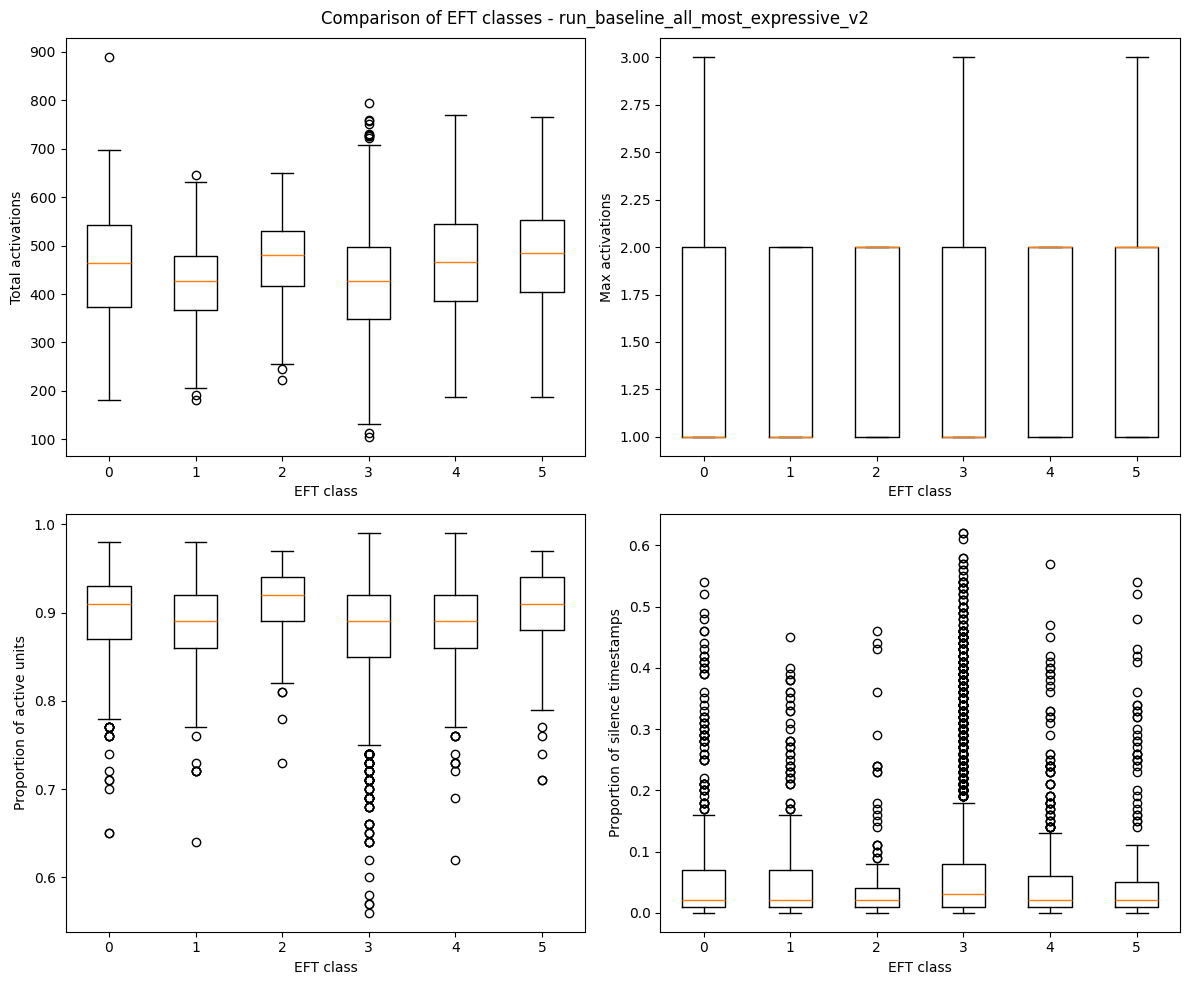

In [16]:
n_cols = 2
n_rows = len(metrics)//n_cols + 1 if len(metrics)%n_cols!=0 else len(metrics)//n_cols
fig, ax = plt.subplots(nrows=n_rows,ncols=n_cols,figsize=(12,10))
for i,metric in enumerate(metrics):
    plot_data = [data[data.EFT_class==c][metric] for c in range(num_j_clusters)]
    ax[i//n_cols,i%n_cols].boxplot(plot_data)
    ax[i//n_cols,i%n_cols].set_xticks(range(1,num_j_clusters+1),range(num_j_clusters))
    ax[i//n_cols,i%n_cols].set_xlabel("EFT class")
    ax[i//n_cols,i%n_cols].set_ylabel(metrics_name[metric])
for i in range(len(metrics),n_cols*n_rows):
    ax[i//n_cols,i%n_cols].axis("off")
fig.suptitle(f"Comparison of EFT classes - {run_name}")
plt.tight_layout()
plt.show()

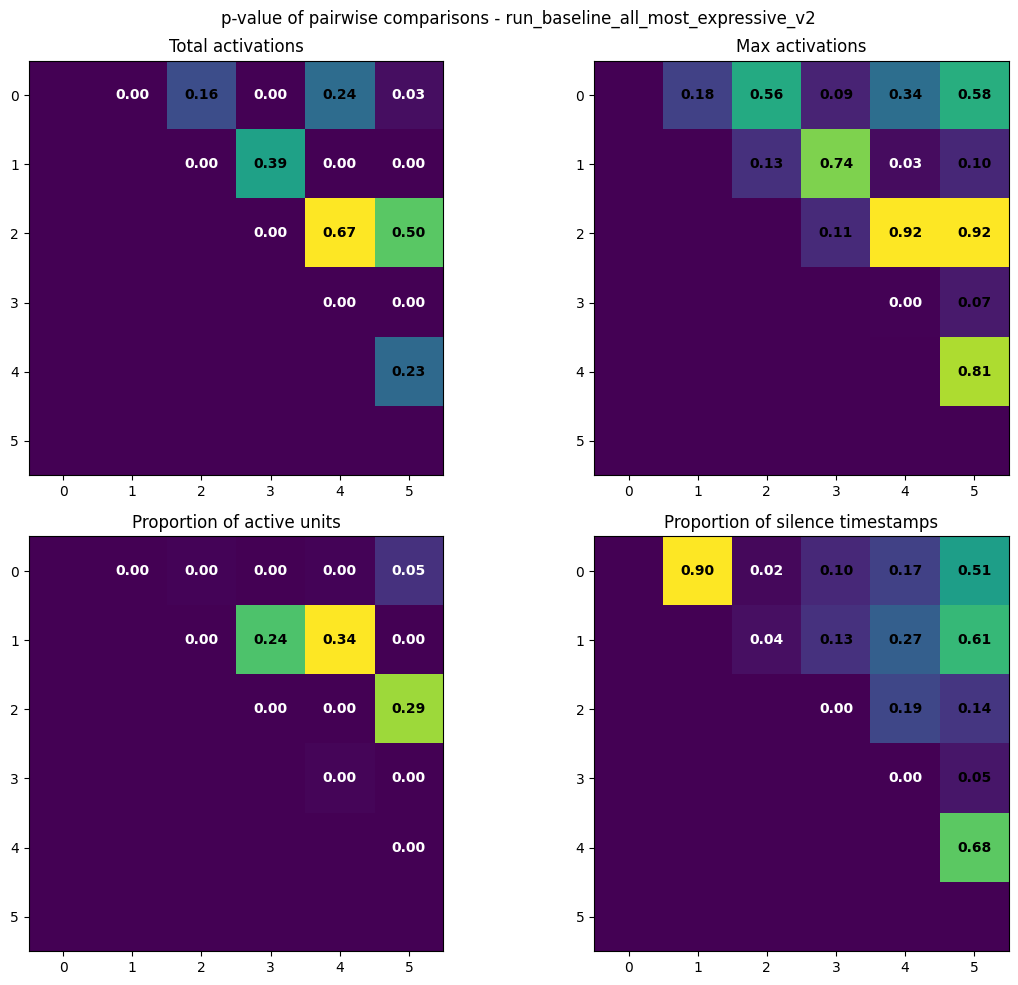

In [17]:
n_cols = 2
n_rows = len(metrics)//n_cols + 1 if len(metrics)%n_cols!=0 else len(metrics)//n_cols
fig, ax = plt.subplots(nrows=n_rows,ncols=n_cols,figsize=(12,10))
for i,metric in enumerate(metrics):
    ax[i//n_cols,i%n_cols].imshow(pvalues[metric])
    ax[i//n_cols,i%n_cols].set_title(metrics_name[metric])
    for (row, col), val in np.ndenumerate(pvalues[metric]):
        text_color = "white" if val < 0.05 else "black"
        label = "" if val == 0 else f"{val:.2f}"
        ax[i//n_cols,i%n_cols].text(col, row, label, ha="center", va="center",fontsize=10, fontweight="bold", color=text_color)
for i in range(len(metrics),n_cols*n_rows):
    ax[i//n_cols,i%n_cols].axis("off")
fig.suptitle(f"p-value of pairwise comparisons - {run_name}")
plt.tight_layout()
plt.show()